In [15]:

#Weekly Market Return Calculation
import pandas as pd

df1 = pd.read_csv("TRD_Week1.csv")  
df2 = pd.read_csv("TRD_Week2.csv")
df = pd.concat([df1, df2], axis=0, ignore_index=True)

df = df[df["Markettype"].isin([1, 4])]
df = df.dropna(subset=["Wretnd"])

# 计算每周市场收益（所有股票平均）
market_return = (
    df.groupby("Trdwnt")["Wretnd"]
    .mean()
    .reset_index()
)

# 重命名列
market_return.columns = ["Trdwnt", "rm_t"]
# 保留6位小数
market_return["rm_t"] = market_return["rm_t"].round(6)
# 保存为CSV
market_return.to_csv("market_return_weekly.csv", index=False)

In [16]:
weeks = sorted(df["Trdwnt"].unique())
mid = len(weeks) // 2

first_half = weeks[:mid]
second_half = weeks[mid:]

In [17]:
#第一期样本个股时间序列回归结果
import statsmodels.api as sm

market_return = (
    df.groupby("Trdwnt")["Wretnd"]
    .mean()
    .reset_index()
    .rename(columns={"Wretnd": "rm_t"})
)

df = df.merge(market_return, on="Trdwnt", how="left")
df_first = df[df["Trdwnt"].isin(first_half)]

# =========================
def stock_reg(group):
    y = group["Wretnd"]
    X = sm.add_constant(group[["rm_t"]], has_constant='add')
    
    model = sm.OLS(y, X).fit()
    
    return pd.Series({
        "alpha": model.params["const"],
        "beta": model.params["rm_t"],
        "t_alpha": model.tvalues["const"],
        "t_beta": model.tvalues["rm_t"],
        "p_alpha": model.pvalues["const"],
        "p_beta": model.pvalues["rm_t"],
        "R2": model.rsquared
    })
    
results = (
    df_first.groupby("Stkcd")
    .apply(stock_reg)
    .dropna()
    .reset_index()
)

results = results.round(6)
results = results.sort_values("beta")

sample_10 = pd.concat([
    results.iloc[[0]],    # 最低β
    results.iloc[[len(results)//4]],
    results.iloc[[len(results)//2]],
    results.iloc[[3*len(results)//4]],
    results.iloc[[-1]]    # 最高β
])

# 再随机补满到10只
remaining = results.drop(sample_10.index)
sample_10 = pd.concat([sample_10, remaining.sample(5, random_state=42)])

print(sample_10)

# 保存结果
sample_10.to_csv("Period1 individual time-series.csv", index=False)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


       Stkcd     alpha      beta   t_alpha     t_beta   p_alpha    p_beta  \
774     2260 -0.099328 -5.608220 -1.111346  -1.578010  0.316982  0.175393   
2696  603179  0.009545  0.806237  1.460991   3.307085  0.146082  0.001177   
1760  600275 -0.009943  1.004385 -1.228876   3.263797  0.221484  0.001426   
1281    2776 -0.004327  1.198257 -0.636874   4.759011  0.525225  0.000005   
482     1256  0.077235  5.449533  0.423268   0.890117  0.745096  0.536969   
1034    2521 -0.002421  0.960994 -0.989249  10.522892  0.324113  0.000000   
1980  600557  0.001573  0.630635  0.354538   3.808633  0.723427  0.000202   
1317    2816 -0.004271  0.952878 -0.973275   5.820114  0.331983  0.000000   
2673  603136  0.003302  0.657109  0.624771   3.332241  0.533058  0.001082   
2512  601816 -0.002595  0.534778 -1.109965   6.168363  0.268802  0.000000   

            R2  
774   0.332454  
2696  0.067123  
1760  0.080303  
1281  0.136725  
482   0.442060  
1034  0.421462  
1980  0.087118  
1317  0.184223  

/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_43123/1754156624.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(stock_reg)


In [18]:
#第一期组合时间序列回归结果
results["group"] = results.index // 50

# merge 分组信息
df_first = df_first.merge(
    results[["Stkcd", "group"]],
    on="Stkcd",
    how="inner"
)

# 8. 计算组合收益（简单平均）
portfolio = (
    df_first.groupby(["Trdwnt", "group"])["Wretnd"]
    .mean()
    .reset_index()
)

# 加入 rm_t
portfolio = portfolio.merge(
    market_return,
    on="Trdwnt",
    how="left"
)

# 9. 读取无风险利率 rf
rf = pd.read_stata("riskfree_w.dta")
rf.columns = ['rf','Trdwnt']
# 确保格式一致
rf["rf"] = rf["rf"].astype(str)

# 假设列名是 rf（如果不是自己 print 看一下）
rf = rf.rename(columns={"rf": "rf_t"})

# merge rf
portfolio = portfolio.merge(rf, on="Trdwnt", how="left")
portfolio["rf_t"] = pd.to_numeric(portfolio["rf_t"], errors="coerce")
# 10. 计算超额收益
portfolio["excess_p"] = portfolio["Wretnd"] - portfolio["rf_t"]
portfolio["excess_m"] = portfolio["rm_t"] - portfolio["rf_t"]

# 11. 组合回归 → β_p
def portfolio_reg(group):
    y = group["excess_p"]
    X = sm.add_constant(group[["excess_m"]], has_constant='add')
    
    model = sm.OLS(y, X).fit()
    
    return pd.Series({
        "alpha_p": model.params.iloc[0],
        "beta_p": model.params.iloc[1],
        "t_alpha": model.tvalues.iloc[0],
        "t_beta": model.tvalues.iloc[1],
        "p_alpha": model.pvalues.iloc[0],
        "p_beta": model.pvalues.iloc[1],
        "R2": model.rsquared
    })

portfolio_results = (
    portfolio.groupby("group")
    .apply(portfolio_reg)
    .reset_index()
    .round(6)
)

print(portfolio_results)

portfolio_results.to_csv("Period1 portfolio time-series.csv", index=False)

    group   alpha_p    beta_p   t_alpha     t_beta   p_alpha  p_beta        R2
0       0 -0.001299  1.121499 -1.323892  30.593851  0.187526     0.0  0.860292
1       1 -0.000177  0.987930 -0.234672  35.100425  0.814779     0.0  0.890177
2       2  0.000095  0.989720  0.118748  33.161558  0.905631     0.0  0.878564
3       3 -0.000289  1.049962 -0.354976  34.529912  0.723100     0.0  0.886931
4       4 -0.000959  1.047675 -0.956010  27.953159  0.340585     0.0  0.837151
..    ...       ...       ...       ...        ...       ...     ...       ...
60     60  0.000245  0.943940  0.311266  32.156429  0.756025     0.0  0.871842
61     61  0.000811  1.061635  0.901890  31.615219  0.368542     0.0  0.868001
62     62  0.000249  1.020647  0.226604  24.846445  0.821036     0.0  0.802430
63     63  0.009037  1.250284  1.576811   5.518510  0.117251     0.0  0.188623
64     64  0.003657  0.883585  1.158265   6.679868  0.249037     0.0  0.269415

[65 rows x 8 columns]


/var/folders/1c/m_xj0h9x5pl4cnk4ptg44l5r0000gn/T/ipykernel_43123/1710925214.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(portfolio_reg)


In [19]:
#第二期股票组合横截面回归结果
df_second = df[df["Trdwnt"].isin(second_half)]
df_second = df_second.merge(
    results[["Stkcd", "group"]],
    on="Stkcd",
    how="inner"
)

portfolio_second = (
    df_second.groupby(["Trdwnt", "group"])["Wretnd"]
    .mean()
    .reset_index()
)

portfolio_second = portfolio_second.merge(
    market_return,
    on="Trdwnt",
    how="left"
)

portfolio_second = portfolio_second.merge(
    rf,
    on="Trdwnt",
    how="left"
)

# 确保 rf 是数值
portfolio_second["rf_t"] = pd.to_numeric(portfolio_second["rf_t"], errors="coerce")
portfolio_second["excess_p"] = portfolio_second["Wretnd"] - portfolio_second["rf_t"]

avg_excess = (
    portfolio_second.groupby("group")["excess_p"]
    .mean()
    .reset_index()
)

avg_excess.columns = ["group", "avg_excess_return"]
beta_p = portfolio_results[["group", "beta_p"]]
cs_data = avg_excess.merge(beta_p, on="group")

import statsmodels.api as sm

y = cs_data["avg_excess_return"]
X = sm.add_constant(cs_data[["beta_p"]], has_constant='add')

model = sm.OLS(y, X).fit()

cs_results = {
    "gamma_0": model.params.iloc[0],
    "gamma_1": model.params.iloc[1],
    "t_gamma_0": model.tvalues.iloc[0],
    "t_gamma_1": model.tvalues.iloc[1],
    "p_gamma_0": model.pvalues.iloc[0],
    "p_gamma_1": model.pvalues.iloc[1],
    "R2": model.rsquared
}

cs_results = pd.Series(cs_results).round(6)

print(cs_results)
cs_results.to_csv("Period2 portfolio cross-sectional.csv", index=True)

gamma_0     -0.000036
gamma_1      0.002652
t_gamma_0   -0.030739
t_gamma_1    2.295593
p_gamma_0    0.975575
p_gamma_1    0.025039
R2           0.077190
dtype: float64


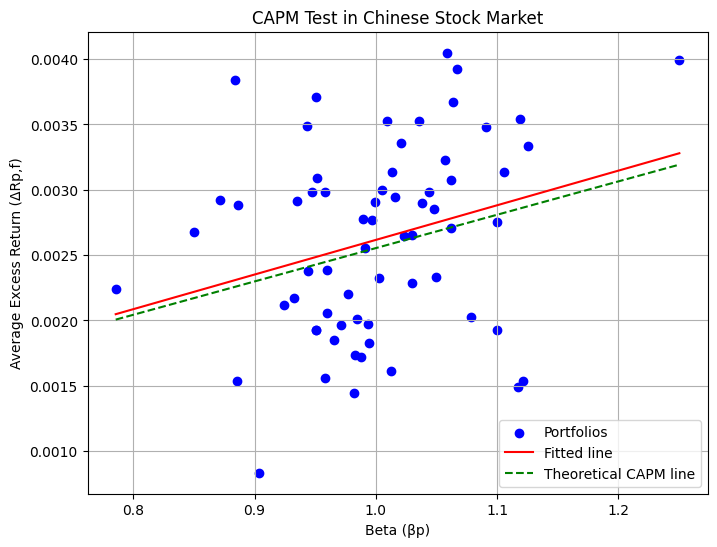

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

x = cs_data["beta_p"]
y = cs_data["avg_excess_return"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

gamma0, gamma1 = model.params

# γ0 = 0
# γ1 = mean market excess return
market_excess = (portfolio_second["rm_t"] - portfolio_second["rf_t"]).mean()

beta_line = np.linspace(x.min(), x.max(), 100)
theoretical_line = market_excess * beta_line  # γ0 = 0

plt.figure(figsize=(8,6))
plt.scatter(x, y, label="Portfolios", color="blue")
# fitted regression line
plt.plot(beta_line,
         gamma0 + gamma1 * beta_line,
         label="Fitted line", color="red")

# theoretical CAPM line
plt.plot(beta_line,
         theoretical_line,
         label="Theoretical CAPM line", color="green", linestyle="--")

plt.xlabel("Beta (βp)")
plt.ylabel("Average Excess Return (ΔRp,f)")
plt.title("CAPM Test in Chinese Stock Market")

plt.legend()
plt.grid(True)
plt.savefig("CAPM_test.png", dpi=300)
